# 03 — Traditional Detector
Detect pulses using a matched filter + threshold. No neural network — just maths.

In [9]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

DATA_PATH = '../data/RadChar-Small.h5'

In [10]:
# load data
with h5py.File(DATA_PATH, 'r') as f:
    iq     = f['iq'][:]
    labels = f['labels'][:]

In [11]:
# compute magnitude of one sample (collapses I and Q into one line)
sample    = iq[0]
magnitude = np.abs(sample)

# matched filter template — a flat block of ones, shaped like a pulse
# length 20 means we expect pulses to be roughly 20 time steps wide
template = np.ones(20)

# slide the template across the magnitude signal and get a score at each position
scores = correlate(magnitude, template, mode='same')

# normalise so scores are easy to compare (peak becomes 1.0)
scores = scores / scores.max()

# detection threshold: a point counts as "signal" if its score clears this line.
# defined here so the plots below have it on a fresh kernel run.
threshold = 0.5

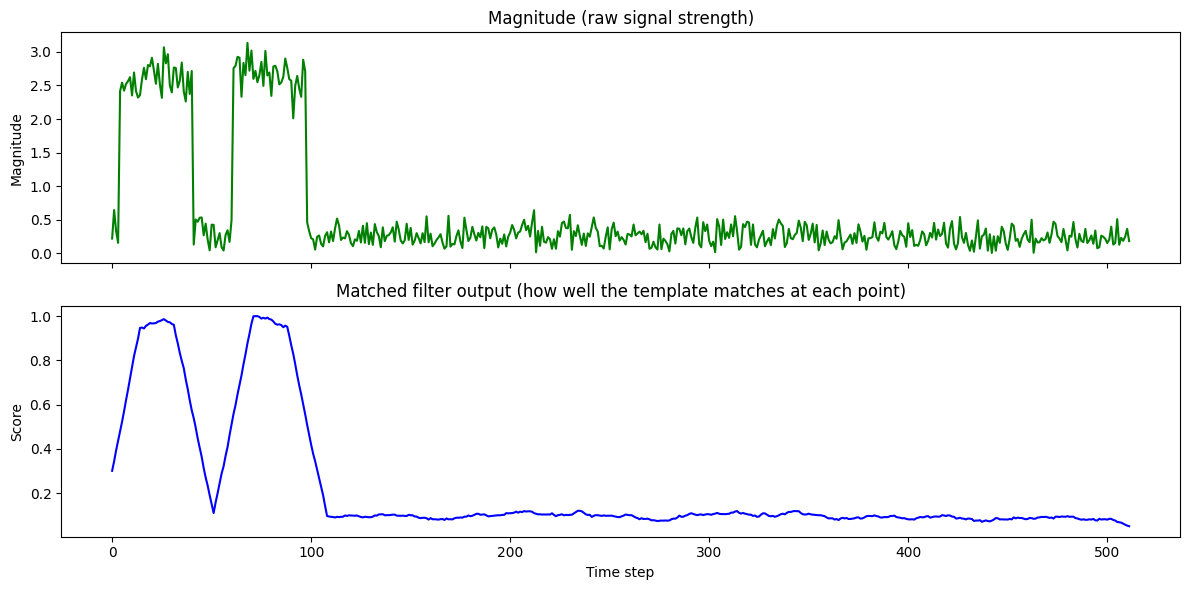

In [12]:
# plot the magnitude and the matched filter scores together
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(magnitude, color='green')
axes[0].set_title('Magnitude (raw signal strength)')
axes[0].set_ylabel('Magnitude')

axes[1].plot(scores, color='blue')
axes[1].set_title('Matched filter output (how well the template matches at each point)')
axes[1].set_ylabel('Score')
axes[1].set_xlabel('Time step')

plt.tight_layout()
plt.show()

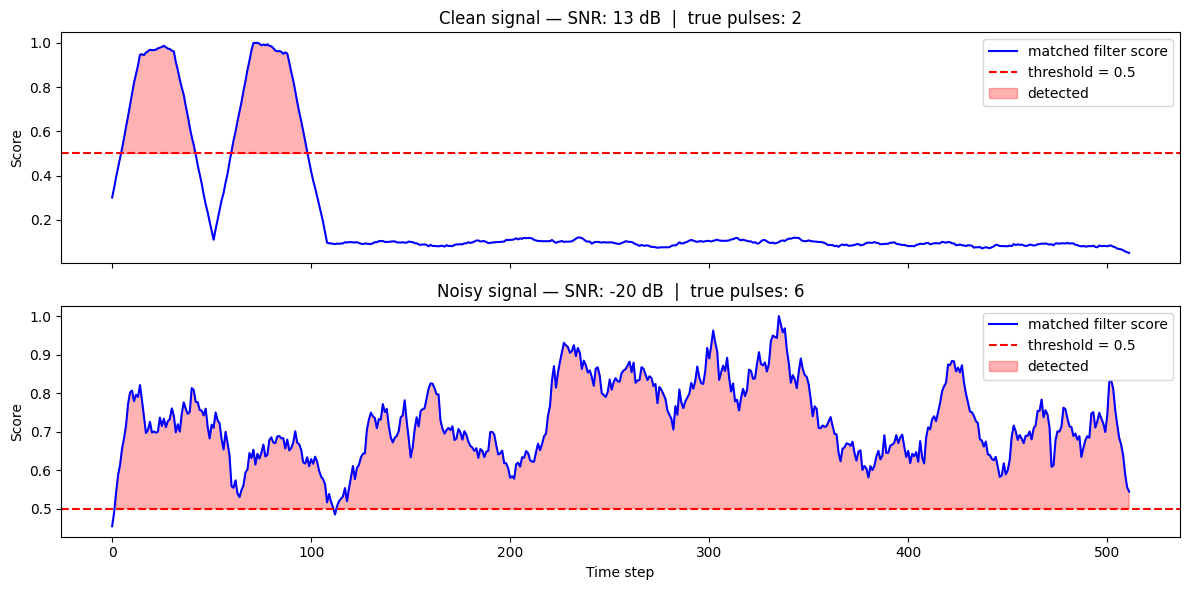

In [ ]:
# what this shows:
# Because we normalise each signal by its OWN peak, the max score is always 1.0,
# so SOMETHING always clears the threshold — even in pure noise. In the clean
# signal the detections line up with the real pulses; in the -20 dB signal the
# "detections" are just noise spikes. This is exactly why a fixed-threshold
# matched filter struggles at low SNR, and motivates the classifier comparison
# in notebook 05.

# find a sample with very low SNR (-20 dB) — the noisiest possible
noisy_idx = np.where(labels['signal_to_noise_ratio'] == -20)[0][0]

noisy_magnitude = np.abs(iq[noisy_idx])
noisy_scores    = correlate(noisy_magnitude, template, mode='same')
noisy_scores    = noisy_scores / noisy_scores.max()

# plot clean vs noisy side by side
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(scores, color='blue', label='matched filter score')
axes[0].axhline(threshold, color='red', linestyle='--', label=f'threshold = {threshold}')
axes[0].fill_between(range(len(scores)), scores, threshold, where=scores > threshold, alpha=0.3, color='red', label='detected')
axes[0].set_title(f'Clean signal — SNR: 13 dB  |  true pulses: {labels[0]["number_of_pulses"]}')
axes[0].set_ylabel('Score')
axes[0].legend()

axes[1].plot(noisy_scores, color='blue', label='matched filter score')
axes[1].axhline(threshold, color='red', linestyle='--', label=f'threshold = {threshold}')
axes[1].fill_between(range(len(noisy_scores)), noisy_scores, threshold, where=noisy_scores > threshold, alpha=0.3, color='red', label='detected')
axes[1].set_title(f'Noisy signal — SNR: -20 dB  |  true pulses: {labels[noisy_idx]["number_of_pulses"]}')
axes[1].set_ylabel('Score')
axes[1].set_xlabel('Time step')
axes[1].legend()

plt.tight_layout()
plt.show()